In [1]:
# ─── Environment Setup (do not edit) ────────────────────────────────────────
import os, sys
from pathlib import Path


# ── 1. Detect platform ──
def _detect_platform():
    # Colab
    try:
        import google.colab  # noqa: F401

        return "colab", False
    except ImportError:
        pass
    # Vast.ai (confident: env var present)
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    # Vast.ai (weak signal: /workspace exists but no env var)
    if Path("/workspace").exists():
        return "vastai", True  # True = uncertain, emit warning
    # Windows
    if sys.platform == "win32":
        return "windows", False
    # Mac
    if sys.platform == "darwin":
        return "mac", False
    # Unknown
    return None, True


PLATFORM, _uncertain = _detect_platform()

# ── 2. Mount Drive (Colab only) ──
if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

# ── 3. Resolve project root ──
try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

if PLATFORM == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
else:
    # notebooks/pipelines/ → go up 2 levels to project root
    PROJECT_ROOT = _nb_path.parents[1]

sys.path.insert(0, str(PROJECT_ROOT))

# ── 4. Select .env file ──
_env_map = {
    "colab": PROJECT_ROOT / ".env.colab",
    "vastai": PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac": PROJECT_ROOT / ".env.mac",
}

if PLATFORM is None:
    print("⚠️  WARNING: Could not detect platform. Falling back to .env (local).")
    print("   To silence this, set PLATFORM explicitly in your .env file.")
    _env_file = PROJECT_ROOT / ".env"
elif _uncertain:
    print(f"⚠️  WARNING: Detected /workspace but VAST_CONTAINERLABEL is not set.")
    print(
        f"   Assuming Vast.ai. To confirm, add VAST_CONTAINERLABEL to your .env.vastai."
    )
    _env_file = _env_map["vastai"]
else:
    _env_file = _env_map[PLATFORM]

# ── 5. Load .env ──
from dotenv import load_dotenv

if not _env_file.exists():
    _fallback = PROJECT_ROOT / ".env"
    print(f"⚠️  WARNING: Expected env file not found: {_env_file}")
    if _fallback.exists():
        print(f"   Falling back to: {_fallback}")
        _env_file = _fallback
    else:
        raise FileNotFoundError(
            f"No .env file found. Copy the correct example file:\n"
            f"  cp .env.{PLATFORM or 'mac'}.example .env.{PLATFORM or 'mac'}\n"
            f"Available: .env.vastai.example | .env.colab.example | .env.mac.example | .env.windows.example"
        )

load_dotenv(_env_file, override=True)

# ── 6. Resolve DATA_ROOT ──
from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

print(f"✅ Platform : {PLATFORM or 'unknown (local fallback)'}")
print(f"✅ Env file : {_env_file}")
print(f"✅ DATA_ROOT: {DATA_ROOT}")
print(f"{'✅' if DATA_ROOT.exists() else '❌'} Path exists: {DATA_ROOT.exists()}")
if not DATA_ROOT.exists():
    print("   DATA_ROOT does not exist. Check your .env path or sync data first.")
# ─────────────────────────────────────────────────────────────────────────────

✅ Platform : mac
✅ Env file : /Users/haila/My File/projects/fake-new-detection/.env.mac
✅ DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis
✅ Path exists: True


# COOLANT Training — Stage 1 Multimodal Alignment

Trains `ResNetCOOLANT` / `PatchedCOOLANT` on Phase 2 HDF5 feature files using dynamic matched/unmatched negatives,
logs metrics to MLflow, saves reproducible checkpoints, plots training curves, evaluates the best checkpoint,
and produces a frozen-checkpoint handoff for Phase 4 MM-ViFactCheck integration.

**Provenance:** Based on `notebooks/all_stage_final/workflow_coolant/2a_train_simultaneous.ipynb` (legacy baseline).
See `docs/COOLANT_WORKFLOW_ANALYSIS.md` for paper vs. repo vs. implementation notes.
See `.planning/phases/03-coolant-training-notebook-stage-1/03-CONTEXT.md` for design decisions.

```
Input:  processed_data/hdf5/coolant_train.h5, coolant_dev.h5, coolant_test.h5
Output: training/checkpoints_coolant/<run_name>/best_model.pth
Phase 4 handoff: frozen ResNetCOOLANT checkpoint plus checkpoint_manifest.json
```


In [2]:
# ── CONFIG ─────────────────────────────────────────────────────────────────
# All tunable parameters and paths live here. Edit this cell only.
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "pipeline" else Path.cwd()

try:
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass

# DATA_ROOT: where large files live (hdf5, checkpoints, mlruns).
# Defaults to DATA_ROOT env var, or PROJECT_ROOT if unset.
DATA_ROOT = (
    Path(os.environ["DATA_ROOT"]) if os.environ.get("DATA_ROOT") else PROJECT_ROOT
)

CONFIG = {
    "paths": {
        "hdf5_dir": DATA_ROOT / "processed_data" / "hdf5",
        "train_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_train.h5",
        "dev_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_dev.h5",
        "test_hdf5": DATA_ROOT / "processed_data" / "hdf5" / "coolant_test.h5",
        "checkpoint_root": DATA_ROOT / "training" / "checkpoints_coolant",
        "mlflow_dir": DATA_ROOT / "mlruns",
    },
    "model": {
        "variant": "ResNetCOOLANT",
        "image_dim": 2048,
        "text_embed_dim": 768,
        "text_seq_len": 128,
        # ResNetCOOLANT / COOLANT_Official constructor keys
        "shared_dim": 128,
        "sim_dim": 64,
        "clip_embed_dim": 64,
        "feature_dim": 96,  # 64 + 16 + 16
        "h_dim": 64,
        "lr": 1e-4,
        "weight_decay": 1e-5,
        "dropout": 0.1,
    },
    "training": {
        "batch_size": 32,
        "max_epochs": 30,
        "patience": 7,
        "negative_shift": 3,
        "min_batch_for_negatives": 4,
        "grad_clip": 1.0,
        "warmup_steps": 200,
        "seed": 42,
        # Loss weights
        "similarity_weight": 0.5,
        "clip_weight": 0.2,
        "detection_weight": 1.0,
    },
    "loss": {
        "cosine_margin": 0.2,
        "label_smoothing": 0.0,
    },
    "mlflow": {
        "experiment_name": "coolant-stage1-training",
    },
    "checkpointing": {
        "selection_metric": "val_accuracy",
        "checkpoint_every": 5,
    },
    "safety": {
        "smoke_test": False,
        "smoke_batches": 2,
        "auto_install_deps": False,
        "resume_from_checkpoint": None,
        "aggressive_memory_cleanup": False,
    },
}

In [3]:
# ── DEPENDENCY PREFLIGHT ────────────────────────────────────────────────────
import importlib, sys

_required = {
    "torch": "torch",
    "h5py": "h5py",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "tqdm": "tqdm",
    "sklearn": "scikit-learn",
    "mlflow": "mlflow",
}

_missing = []
for mod, pkg in _required.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        _missing.append(pkg)

if _missing:
    if CONFIG["safety"]["auto_install_deps"]:
        import subprocess

        subprocess.check_call([sys.executable, "-m", "pip", "install"] + _missing)
        print(f"Installed: {_missing}")
    else:
        print("Missing dependencies. Install with one of:")
        print("  pip install mlflow seaborn scikit-learn tqdm h5py")
        print(
            "  conda install -n fake_news mlflow seaborn scikit-learn tqdm h5py -c conda-forge"
        )
        raise RuntimeError(
            f"Missing packages: {_missing}. Set CONFIG['safety']['auto_install_deps']=True to auto-install."
        )
else:
    print("All dependencies satisfied.")

All dependencies satisfied.


In [5]:
# ── IMPORTS AND SRC SETUP ──────────────────────────────────────────────────
import sys, os, gc, json, csv, random, hashlib, types
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

# Ensure src/ is on the path
_root = PROJECT_ROOT
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Create checkpoint root
CONFIG["paths"]["checkpoint_root"].mkdir(parents=True, exist_ok=True)

# Import project utilities
from src.models.resnet_coolant import ResNetCOOLANT
from src.preprocessing.coolant.pair_dataset import create_coolant_dataloaders
from src.preprocessing.coolant.training_utils import (
    make_coolant_pairs,
    make_detection_batch,
    soft_cross_entropy,
)

print(f"Project root: {_root}")
print(f"PyTorch: {torch.__version__}")

/Users/haila/My File/projects/fake-new-detection/src/preprocessing/text_preprocessing.py:210: SyntaxWarning: invalid escape sequence '\['
  vietnamese_punctuation = r'[.,;:!?""' "(){}\[\]\\/|`~@#$%^&*+=<>—–]"


Project root: /Users/haila/My File/projects/fake-new-detection
PyTorch: 2.12.0


## Step 1: Validate Phase 2 HDF5 Inputs

Checks that Phase 2 preprocessing has run and that the HDF5 files have the expected schema and tensor shapes
before training starts. Fails early with clear instructions if files are missing or malformed.


In [6]:
def validate_coolant_hdf5(path, split_name):
    """Open HDF5 file and verify required datasets and shapes."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"HDF5 file missing for split '{split_name}': {path}\n"
            "Run Phase 2 preprocessing first: notebooks/pipeline/02_preprocessing.ipynb"
        )
    with h5py.File(path, "r") as f:
        for key in ("caption_features", "image_features"):
            if key not in f:
                raise KeyError(
                    f"'{key}' missing from {path.name}. "
                    "Run Phase 2 preprocessing first: notebooks/pipeline/02_preprocessing.ipynb"
                )
        cap_shape = f["caption_features"].shape
        img_shape = f["image_features"].shape
        n = cap_shape[0]

        # Shape constraints (caption stored as [N, seq_len, embed_dim] in HDF5)
        if cap_shape[1] != CONFIG["model"]["text_seq_len"]:
            raise ValueError(
                f"{split_name}: caption_features.shape[1]={cap_shape[1]} "
                f"!= CONFIG text_seq_len={CONFIG['model']['text_seq_len']}"
            )
        if cap_shape[2] != CONFIG["model"]["text_embed_dim"]:
            raise ValueError(
                f"{split_name}: caption_features.shape[2]={cap_shape[2]} "
                f"!= CONFIG text_embed_dim={CONFIG['model']['text_embed_dim']}"
            )
        if img_shape[1] != CONFIG["model"]["image_dim"]:
            raise ValueError(
                f"{split_name}: image_features.shape[1]={img_shape[1]} "
                f"!= CONFIG image_dim={CONFIG['model']['image_dim']}"
            )
    size_mb = path.stat().st_size / 1e6
    return {
        "split": split_name,
        "rows": n,
        "caption_shape": cap_shape[1:],
        "image_shape": img_shape[1:],
        "size_mb": round(size_mb, 2),
    }


hdf5_stats = []
for _split, _key in [
    ("train", "train_hdf5"),
    ("dev", "dev_hdf5"),
    ("test", "test_hdf5"),
]:
    hdf5_stats.append(validate_coolant_hdf5(CONFIG["paths"][_key], _split))

print(pd.DataFrame(hdf5_stats).to_string(index=False))
print("\nAll Phase 2 HDF5 inputs validated.")

split  rows caption_shape image_shape  size_mb
train  6724    (128, 768)     (2048,)  2701.70
  dev   862    (128, 768)     (2048,)   346.34
 test  2053    (128, 768)     (2048,)   824.90

All Phase 2 HDF5 inputs validated.


## Step 2: Device, Seed, and DataLoaders

Selects the best available compute device, seeds all RNGs for reproducibility, then
creates train/dev/test DataLoaders from the validated Phase 2 HDF5 files.


In [7]:
def select_device():
    """Select best available device: cuda > mps > cpu."""
    if torch.cuda.is_available():
        dev = torch.device("cuda")
        mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"Device: cuda ({torch.cuda.get_device_name(0)}, {mem:.1f} GB)")
    elif torch.backends.mps.is_available():
        dev = torch.device("mps")
        print("Device: mps (Apple Silicon). For full training, prefer a CUDA GPU.")
    else:
        dev = torch.device("cpu")
        print(
            "Device: cpu. For full training, prefer a CUDA GPU. Use smoke_test=True for local validation."
        )
    return dev


def seed_everything(seed):
    """Seed Python random, NumPy, PyTorch, and CUDA for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed: {seed}")


DEVICE = select_device()
seed_everything(CONFIG["training"]["seed"])

# Create dataloaders
loaders, datasets = create_coolant_dataloaders(
    str(CONFIG["paths"]["train_hdf5"]),
    str(CONFIG["paths"]["dev_hdf5"]),
    str(CONFIG["paths"]["test_hdf5"]),
    batch_size=CONFIG["training"]["batch_size"],
)

# Smoke-test wrapper: limit to N batches per loader
if CONFIG["safety"]["smoke_test"]:
    smoke_batches = CONFIG["safety"].get("smoke_batches", 2)
    print(f"SMOKE TEST: limiting to {smoke_batches} batches per split")
    from itertools import islice

    class _SmokeLimitedLoader:
        def __init__(self, loader, n):
            self._loader = loader
            self._n = n

        def __iter__(self):
            return islice(self._loader, self._n)

        def __len__(self):
            return min(self._n, len(self._loader))

    loaders = {k: _SmokeLimitedLoader(v, smoke_batches) for k, v in loaders.items()}

# Verify batch shapes
print("\nVerifying train batch shapes...")
_cap, _img, _ = next(iter(loaders["train"]))
print(
    f"  caption: {tuple(_cap.shape)}  (expected [B, 768, 128])  # [B, embed_dim, seq_len]"
)
print(f"  image:   {tuple(_img.shape)}  (expected [B, 2048])")

Device: mps (Apple Silicon). For full training, prefer a CUDA GPU.
Seed: 42
CoolantPairDataset: 6724 pairs from coolant_train.h5
CoolantPairDataset: 862 pairs from coolant_dev.h5
CoolantPairDataset: 2053 pairs from coolant_test.h5

COOLANT DataLoaders created:
  Train: 211 batches (6724 pairs)
  Dev:   27 batches (862 pairs)
  Test:  65 batches (2053 pairs)

Verifying train batch shapes...
  caption: (32, 768, 128)  (expected [B, 768, 128])  # [B, embed_dim, seq_len]
  image:   (32, 2048)  (expected [B, 2048])


## Step 3: Build and Patch ResNetCOOLANT

Constructs `ResNetCOOLANT` (alias for `PatchedCOOLANT`) with the config-derived architecture,
then patches internal layer dimensions so the model accepts 2048-dim ResNet50 image features
and 768-dim PhoBERT token embeddings.


In [8]:
def build_model(config, device):
    """Build and patch ResNetCOOLANT for the configured feature dimensions."""
    model = ResNetCOOLANT.from_config(config["model"], device=str(device))

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    sim_p = sum(p.numel() for p in model.similarity_module.parameters())
    clip_p = sum(p.numel() for p in model.clip_module.parameters())
    det_p = sum(p.numel() for p in model.detection_module.parameters())
    print(f"Parameters — total: {total:,}  trainable: {trainable:,}")
    print(f"  similarity_module: {sim_p:,}")
    print(f"  clip_module:       {clip_p:,}")
    print(f"  detection_module:  {det_p:,}")
    return model


model = build_model(CONFIG, DEVICE)
print(f"\nModel variant: {CONFIG['model']['variant']}")

Parameters — total: 5,610,288  trainable: 5,610,288
  similarity_module: 1,003,266
  clip_module:       754,305
  detection_module:  3,852,717

Model variant: ResNetCOOLANT


## Step 4: Losses, Optimizers, and Schedulers

Follows the official COOLANT training recipe: separate optimizers for each module,
composite losses (cosine similarity, CLIP contrastive CE + soft CE, detection CE + KL ambiguity),
and per-step warmup cosine LR scheduling.


In [9]:
# Losses
loss_cos = nn.CosineEmbeddingLoss(margin=CONFIG["loss"]["cosine_margin"])
loss_ce = nn.CrossEntropyLoss(label_smoothing=CONFIG["loss"]["label_smoothing"])
loss_kl = nn.KLDivLoss(reduction="batchmean")

# Separate optimizers per module (official COOLANT approach)
optim_similarity = torch.optim.Adam(
    model.similarity_module.parameters(),
    lr=CONFIG["model"]["lr"],
    weight_decay=CONFIG["model"]["weight_decay"],
)
optim_clip = torch.optim.Adam(
    model.clip_module.parameters(),
    lr=CONFIG["model"]["lr"],
    weight_decay=CONFIG["model"]["weight_decay"],
)
optim_detection = torch.optim.Adam(
    model.detection_module.parameters(),
    lr=CONFIG["model"]["lr"],
    weight_decay=CONFIG["model"]["weight_decay"],
)
OPTIMIZERS = {
    "similarity": optim_similarity,
    "clip": optim_clip,
    "detection": optim_detection,
}


def make_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps):
    """Per-step warmup cosine LR scheduler."""

    def _lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / max(1, warmup_steps)
        progress = float(current_step - warmup_steps) / max(
            1, total_steps - warmup_steps
        )
        return max(
            0.0,
            0.5 * (1.0 + torch.cos(torch.tensor(3.141592653589793 * progress)).item()),
        )

    return torch.optim.lr_scheduler.LambdaLR(optimizer, _lr_lambda)


_total_steps = CONFIG["training"]["max_epochs"] * len(loaders["train"])
_warmup = CONFIG["training"]["warmup_steps"]
schedulers = {
    k: make_warmup_cosine_scheduler(opt, _warmup, _total_steps)
    for k, opt in OPTIMIZERS.items()
}

print(f"Optimizers: similarity, clip, detection (Adam, lr={CONFIG['model']['lr']})")
print(f"Scheduler: warmup_cosine — warmup_steps={_warmup}, total_steps={_total_steps}")

Optimizers: similarity, clip, detection (Adam, lr=0.0001)
Scheduler: warmup_cosine — warmup_steps=200, total_steps=6330


In [10]:
# ── ONE-BATCH FORWARD/LOSS SANITY CHECK ────────────────────────────────────
print("Running one-batch forward/loss sanity check...")
model.train()
_caption_s, _image_s, _ = next(iter(loaders["train"]))
_caption_s = _caption_s.to(DEVICE)
_image_s = _image_s.to(DEVICE)

_cap_a, _img_m, _img_u = make_coolant_pairs(
    _caption_s, _image_s, shift=CONFIG["training"]["negative_shift"]
)
_out = model(_cap_a, _img_m)
_ta, _ia = _out["text_aligned_clip"], _out["image_aligned_clip"]

_sim_lbl = torch.ones(_cap_a.size(0), device=DEVICE)
_sim_loss = loss_cos(_out["similarity_pred"][:, :1].expand_as(_ta), _ta, _sim_lbl)
_clip_loss = model.compute_clip_loss(_ta, _ia)

_det_cap, _det_img, _det_lbl = make_detection_batch(
    _caption_s, _image_s, shift=CONFIG["training"]["negative_shift"]
)
_det_cap, _det_img, _det_lbl = (
    _det_cap.to(DEVICE),
    _det_img.to(DEVICE),
    _det_lbl.to(DEVICE),
)
_det_out = model(_det_cap, _det_img)
_det_loss = model.compute_detection_loss(
    _det_out["detection_logits"],
    _det_lbl,
    _det_out["attention_weights"],
    _det_out["ambiguity_weights"],
)

print(
    f"  sim_loss:  {_sim_loss.item():.4f}  {'OK' if torch.isfinite(_sim_loss) else 'NaN/Inf!'}"
)
print(
    f"  clip_loss: {_clip_loss.item():.4f}  {'OK' if torch.isfinite(_clip_loss) else 'NaN/Inf!'}"
)
print(
    f"  det_loss:  {_det_loss.item():.4f}  {'OK' if torch.isfinite(_det_loss) else 'NaN/Inf!'}"
)
print("Sanity check passed.")

Running one-batch forward/loss sanity check...
  sim_loss:  0.9901  OK
  clip_loss: 3.4648  OK
  det_loss:  0.7709  OK
Sanity check passed.


## Step 5: MLflow and Run Directory Setup

Creates a timestamped run directory under `training/checkpoints_coolant/` and configures MLflow.
If MLflow fails, training continues with local artifacts only.


In [11]:
import mlflow

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = f"coolant_stage1_{timestamp}"

run_dir = CONFIG["paths"]["checkpoint_root"] / run_name
artifact_dir = run_dir / "artifacts"
run_dir.mkdir(parents=True, exist_ok=True)
artifact_dir.mkdir(parents=True, exist_ok=True)
print(f"Run dir: {run_dir}")

mlflow_enabled = False
mlflow_run_id = None

try:
    mlflow.set_tracking_uri(CONFIG["paths"]["mlflow_dir"].as_uri())
    mlflow.set_experiment(CONFIG["mlflow"]["experiment_name"])
    _mlflow_run = mlflow.start_run(run_name=run_name)
    mlflow_run_id = _mlflow_run.info.run_id
    mlflow.log_params(
        {
            "variant": CONFIG["model"]["variant"],
            "batch_size": CONFIG["training"]["batch_size"],
            "max_epochs": CONFIG["training"]["max_epochs"],
            "patience": CONFIG["training"]["patience"],
            "lr": CONFIG["model"]["lr"],
            "grad_clip": CONFIG["training"]["grad_clip"],
            "smoke_test": CONFIG["safety"]["smoke_test"],
            "seed": CONFIG["training"]["seed"],
        }
    )
    mlflow_enabled = True
    print(f"MLflow run: {mlflow_run_id}")
except Exception as _mlflow_err:
    print(f"MLflow disabled; continuing with local artifacts only ({_mlflow_err})")

Run dir: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928
MLflow disabled; continuing with local artifacts only (The filesystem tracking backend (e.g., './mlruns') is in maintenance mode and will not receive further updates. Please migrate to a database backend (e.g., 'sqlite:///mlflow.db') to access the latest MLflow features. The `mlflow migrate-filestore` tool migrates your existing data losslessly. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance. If the filesystem backend is required for your workflow, set `MLFLOW_ALLOW_FILE_STORE=true` to opt out of this exception.)


## Step 6: Checkpoint and Manifest Helpers

Utilities for saving reproducible checkpoints (with embedded config and metadata),
writing `checkpoint_manifest.json` for the Phase 4 handoff contract,
and loading checkpoints for resumption or evaluation.


In [12]:
def config_to_jsonable(cfg):
    """Recursively convert Path and non-JSON-serializable values for serialization."""
    if isinstance(cfg, dict):
        return {k: config_to_jsonable(v) for k, v in cfg.items()}
    elif isinstance(cfg, Path):
        return str(cfg)
    elif isinstance(cfg, (list, tuple)):
        return [config_to_jsonable(v) for v in cfg]
    return cfg


def compute_config_hash(config):
    """Deterministic SHA-256 hash of the serializable config."""
    cfg_str = json.dumps(config_to_jsonable(config), sort_keys=True)
    return hashlib.sha256(cfg_str.encode()).hexdigest()[:16]


def save_checkpoint(
    path,
    model,
    epoch,
    config,
    history,
    metrics,
    selection_metric,
    mlflow_run_id=None,
    optimizer_states=None,
    scheduler_states=None,
):
    """Save a reproducible COOLANT training checkpoint."""
    ckpt = {
        "model_state_dict": model.state_dict(),
        "similarity_module_state_dict": model.similarity_module.state_dict(),
        "clip_module_state_dict": model.clip_module.state_dict(),
        "detection_module_state_dict": model.detection_module.state_dict(),
        "config": config_to_jsonable(config),
        "config_hash": compute_config_hash(config),
        "epoch": epoch,
        "metrics": metrics,
        "selection_metric": selection_metric,
        "training_history": history,
        "feature_dims": {
            "image": config["model"]["image_dim"],
            "text_embed": config["model"]["text_embed_dim"],
            "text_seq": config["model"]["text_seq_len"],
        },
        "freeze_for_stage2": True,
        "mlflow_run_id": mlflow_run_id,
    }
    if optimizer_states:
        ckpt["optimizer_states"] = optimizer_states
    if scheduler_states:
        ckpt["scheduler_states"] = scheduler_states
    torch.save(ckpt, path)


def write_checkpoint_manifest(
    manifest_path,
    best_checkpoint_path,
    best_epoch,
    best_metrics,
    config_hash,
    mlflow_enabled,
    mlflow_run_id,
):
    """Write checkpoint_manifest.json documenting the Phase 4 handoff contract."""
    manifest = {
        "best_checkpoint_path": str(best_checkpoint_path),
        "best_epoch": best_epoch,
        "selection_metric": "val_accuracy",
        "best_metrics": best_metrics,
        "config_hash": config_hash,
        "freeze_for_stage2": True,
        "mlflow_enabled": mlflow_enabled,
        "mlflow_run_id": mlflow_run_id,
        "expected_input_shapes": {
            "caption_features": [
                "batch",
                CONFIG["model"]["text_embed_dim"],
                CONFIG["model"]["text_seq_len"],
            ],
            "image_features": ["batch", CONFIG["model"]["image_dim"]],
        },
        "stage2_output_keys": [
            "text_aligned_clip",
            "image_aligned_clip",
            "attention_weights",
            "detection_logits",
            "fake_prob",
        ],
    }
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"Manifest written: {manifest_path}")


def load_training_checkpoint(path, model, optimizers=None, schedulers=None):
    """Load checkpoint for explicit RESUME_FROM_CHECKPOINT only."""
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizers and "optimizer_states" in ckpt:
        for k, opt in optimizers.items():
            if k in ckpt["optimizer_states"]:
                opt.load_state_dict(ckpt["optimizer_states"][k])
    if schedulers and "scheduler_states" in ckpt:
        for k, sch in schedulers.items():
            if k in ckpt["scheduler_states"]:
                sch.load_state_dict(ckpt["scheduler_states"][k])
    print(f"Resumed from epoch {ckpt.get('epoch', '?')}: {path}")
    return ckpt


# Optional resume
_resume_path = CONFIG["safety"]["resume_from_checkpoint"]
start_epoch = 0
if _resume_path:
    _ckpt_data = load_training_checkpoint(_resume_path, model, OPTIMIZERS, schedulers)
    start_epoch = _ckpt_data.get("epoch", 0) + 1

print("Checkpoint helpers ready.")
print(f"Config hash: {compute_config_hash(CONFIG)}")

Checkpoint helpers ready.
Config hash: 214c86b75649a413


## Step 7: Training and Validation Functions

Core training loop helpers: memory cleanup, finite-loss assertions, per-epoch train/eval functions,
and classification metrics (accuracy, macro-F1, per-class precision/recall).


In [13]:
def cleanup_memory(device, aggressive=False):
    """Free unused memory at epoch/eval boundaries."""
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
        if aggressive:
            torch.cuda.synchronize()


def assert_finite_loss(loss, loss_components):
    """Stop training if any loss is NaN or Inf."""
    if not torch.isfinite(loss):
        print("NaN/Inf loss detected. Loss components:")
        for k, v in loss_components.items():
            print(f"  {k}: {v}")
        raise FloatingPointError(
            f"NaN/Inf in total loss: {loss.item()}. Inspect loss components above."
        )


def compute_classification_metrics(y_true, y_pred, prefix):
    """Return accuracy, macro-F1, per-class precision/recall."""
    acc = (np.array(y_pred) == np.array(y_true)).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    real_prec = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    real_rec = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    fake_prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    fake_rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    return {
        f"{prefix}_accuracy": round(float(acc), 4),
        f"{prefix}_macro_f1": round(float(macro_f1), 4),
        f"{prefix}_real_precision": round(float(real_prec), 4),
        f"{prefix}_real_recall": round(float(real_rec), 4),
        f"{prefix}_fake_precision": round(float(fake_prec), 4),
        f"{prefix}_fake_recall": round(float(fake_rec), 4),
    }


def train_one_epoch(
    epoch, model, loaders, optimizers, schedulers, losses, device, config
):
    """Train all three COOLANT modules for one epoch."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    skipped_batches = 0
    n_batches = 0

    min_batch = config["training"]["min_batch_for_negatives"]
    grad_clip = config["training"]["grad_clip"]

    pbar = tqdm(loaders["train"], desc=f"Epoch {epoch:02d} [train]", leave=False)
    for caption, image, _ in pbar:
        if caption.size(0) < min_batch:
            skipped_batches += 1
            continue

        caption, image = caption.to(device), image.to(device)

        # ── Similarity + CLIP task ──────────────────────────────────────────
        cap_a, img_m, img_u = make_coolant_pairs(
            caption, image, shift=CONFIG["training"]["negative_shift"]
        )
        out_m = model(cap_a, img_m)
        out_u = model(cap_a, img_u)

        ta_m, ia_m = out_m["text_aligned_clip"], out_m["image_aligned_clip"]
        ta_u, ia_u = out_u["text_aligned_clip"], out_u["image_aligned_clip"]

        # Cosine embedding loss: matched=+1, unmatched=-1
        lbl_m = torch.ones(cap_a.size(0), device=device)
        lbl_u = -torch.ones(cap_a.size(0), device=device)
        sim_loss = (
            losses["cos"](ta_m, ia_m, lbl_m) + losses["cos"](ta_u, ia_u, lbl_u)
        ) * 0.5

        # CLIP contrastive
        clip_loss = model.compute_clip_loss(ta_m, ia_m)

        # Soft CE on CLIP similarity for distillation
        clip_logits = torch.matmul(ia_m, ta_m.T) * torch.exp(
            model.clip_module.temperature
        )
        soft_tgt = F.softmax(clip_logits.detach(), dim=1)
        soft_loss = soft_cross_entropy(clip_logits, soft_tgt)

        task1_loss = config["training"]["similarity_weight"] * sim_loss + config[
            "training"
        ]["clip_weight"] * (clip_loss + soft_loss)

        for opt in (optimizers["similarity"], optimizers["clip"]):
            opt.zero_grad()
        task1_loss.backward()
        for k in ("similarity", "clip"):
            torch.nn.utils.clip_grad_norm_(
                (
                    model.similarity_module.parameters()
                    if k == "similarity"
                    else model.clip_module.parameters()
                ),
                grad_clip,
            )
            optimizers[k].step()
            schedulers[k].step()

        # ── Detection task ─────────────────────────────────────────────────
        det_cap, det_img, det_lbl = make_detection_batch(
            caption, image, shift=CONFIG["training"]["negative_shift"]
        )
        det_cap, det_img, det_lbl = (
            det_cap.to(device),
            det_img.to(device),
            det_lbl.to(device),
        )
        det_out = model(det_cap, det_img)
        det_loss = model.compute_detection_loss(
            det_out["detection_logits"],
            det_lbl,
            det_out["attention_weights"],
            det_out["ambiguity_weights"],
        )

        assert_finite_loss(
            det_loss, {"task1_loss": task1_loss.item(), "det_loss": det_loss.item()}
        )

        optimizers["detection"].zero_grad()
        det_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.detection_module.parameters(), grad_clip)
        optimizers["detection"].step()
        schedulers["detection"].step()

        # Metrics
        batch_loss = task1_loss.item() + det_loss.item()
        total_loss += batch_loss
        n_batches += 1
        preds = det_out["detection_logits"].argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(det_lbl.cpu().numpy())
        pbar.set_postfix(loss=f"{batch_loss:.4f}", skipped=skipped_batches)

    cleanup_memory(
        device, aggressive=config["safety"].get("aggressive_memory_cleanup", False)
    )
    avg_loss = total_loss / max(1, n_batches)
    metrics = compute_classification_metrics(all_labels, all_preds, "train")
    metrics["train_loss"] = round(avg_loss, 4)
    metrics["skipped_batches"] = skipped_batches
    return metrics


def evaluate(model, loader, device, config, split_name):
    """Evaluate model on a split; return loss, metrics, and confusion matrix."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    n_batches = 0

    with torch.no_grad():
        for caption, image, _ in tqdm(loader, desc=f"  [{split_name}]", leave=False):
            caption, image = caption.to(device), image.to(device)
            det_cap, det_img, det_lbl = make_detection_batch(
                caption, image, shift=CONFIG["training"]["negative_shift"]
            )
            det_cap, det_img, det_lbl = (
                det_cap.to(device),
                det_img.to(device),
                det_lbl.to(device),
            )
            det_out = model(det_cap, det_img)
            loss = model.compute_detection_loss(
                det_out["detection_logits"],
                det_lbl,
                det_out["attention_weights"],
                det_out["ambiguity_weights"],
            )
            total_loss += loss.item()
            n_batches += 1
            preds = det_out["detection_logits"].argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(det_lbl.cpu().numpy())

    cleanup_memory(device)
    avg_loss = total_loss / max(1, n_batches)
    metrics = compute_classification_metrics(all_labels, all_preds, split_name)
    metrics[f"{split_name}_loss"] = round(avg_loss, 4)
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1]).tolist()
    metrics["confusion_matrix"] = cm
    return metrics


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## Step 8: Run Training

Epoch loop with early stopping on validation accuracy. Logs per-epoch metrics to MLflow,
saves periodic and best checkpoints, and handles CUDA OOM and keyboard interrupt gracefully.


In [14]:
_LOSSES = {"cos": loss_cos, "ce": loss_ce, "kl": loss_kl}
CHECKPOINT_EVERY = CONFIG["checkpointing"]["checkpoint_every"]

history = []
best_val_acc = -1.0
best_val_f1 = -1.0
best_epoch = -1
best_ckpt_path = run_dir / "best_model.pth"
best_f1_ckpt_path = run_dir / "best_macro_f1.pth"
patience_counter = 0

print(
    f"Starting training — max_epochs={CONFIG['training']['max_epochs']}, "
    f"patience={CONFIG['training']['patience']}, device={DEVICE}"
)
print()

try:
    for epoch in range(start_epoch, CONFIG["training"]["max_epochs"]):
        # ── Train ────────────────────────────────────────────────────────
        train_metrics = train_one_epoch(
            epoch, model, loaders, OPTIMIZERS, schedulers, _LOSSES, DEVICE, CONFIG
        )

        # ── Validate ─────────────────────────────────────────────────────
        val_metrics = evaluate(model, loaders["dev"], DEVICE, CONFIG, "val")

        # ── Epoch record ─────────────────────────────────────────────────
        epoch_record = {
            "epoch": epoch,
            "train_loss": train_metrics["train_loss"],
            "train_accuracy": train_metrics["train_accuracy"],
            "train_macro_f1": train_metrics["train_macro_f1"],
            "val_loss": val_metrics["val_loss"],
            "val_accuracy": val_metrics["val_accuracy"],
            "val_macro_f1": val_metrics["val_macro_f1"],
            "lr_similarity": OPTIMIZERS["similarity"].param_groups[0]["lr"],
            "lr_clip": OPTIMIZERS["clip"].param_groups[0]["lr"],
            "lr_detection": OPTIMIZERS["detection"].param_groups[0]["lr"],
            "skipped_batches": train_metrics["skipped_batches"],
            "checkpoint_path": None,
        }

        # ── MLflow logging ────────────────────────────────────────────────
        if mlflow_enabled:
            try:
                mlflow.log_metrics(
                    {
                        "train_loss": epoch_record["train_loss"],
                        "train_accuracy": epoch_record["train_accuracy"],
                        "train_macro_f1": epoch_record["train_macro_f1"],
                        "val_loss": epoch_record["val_loss"],
                        "val_accuracy": epoch_record["val_accuracy"],
                        "val_macro_f1": epoch_record["val_macro_f1"],
                        "skipped_batches": epoch_record["skipped_batches"],
                    },
                    step=epoch,
                )
            except Exception:
                pass  # MLflow logging is best-effort

        # ── Periodic checkpoint ────────────────────────────────────────────
        if (epoch + 1) % CHECKPOINT_EVERY == 0:
            per_ckpt = run_dir / f"checkpoint_epoch_{epoch}.pth"
            save_checkpoint(
                per_ckpt,
                model,
                epoch,
                CONFIG,
                history,
                {**train_metrics, **val_metrics},
                CONFIG["checkpointing"]["selection_metric"],
                mlflow_run_id,
                optimizer_states={k: opt.state_dict() for k, opt in OPTIMIZERS.items()},
                scheduler_states={k: sch.state_dict() for k, sch in schedulers.items()},
            )
            epoch_record["checkpoint_path"] = str(per_ckpt)

        # ── Best val_accuracy checkpoint ───────────────────────────────────
        val_acc = val_metrics["val_accuracy"]
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            save_checkpoint(
                best_ckpt_path,
                model,
                epoch,
                CONFIG,
                history,
                {**train_metrics, **val_metrics},
                CONFIG["checkpointing"]["selection_metric"],
                mlflow_run_id,
            )
            print(
                f"  ★ Best val_accuracy={val_acc:.4f} at epoch {epoch} → {best_ckpt_path.name}"
            )
        else:
            patience_counter += 1

        # ── Best val_macro_f1 checkpoint ───────────────────────────────────
        val_f1 = val_metrics["val_macro_f1"]
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            save_checkpoint(
                best_f1_ckpt_path,
                model,
                epoch,
                CONFIG,
                history,
                {**train_metrics, **val_metrics},
                "val_macro_f1",
                mlflow_run_id,
            )

        history.append(epoch_record)

        # ── Persist history ────────────────────────────────────────────────
        _hist_json = artifact_dir / "training_history.json"
        _hist_csv = artifact_dir / "training_history.csv"
        with open(_hist_json, "w") as f:
            json.dump(history, f, indent=2)
        pd.DataFrame(history).to_csv(_hist_csv, index=False)

        # ── Epoch summary ──────────────────────────────────────────────────
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={epoch_record['train_loss']:.4f} "
            f"train_acc={epoch_record['train_accuracy']:.4f} "
            f"val_loss={epoch_record['val_loss']:.4f} "
            f"val_acc={epoch_record['val_accuracy']:.4f} "
            f"val_f1={epoch_record['val_macro_f1']:.4f} "
            f"(patience {patience_counter}/{CONFIG['training']['patience']})"
        )

        # ── Early stopping ─────────────────────────────────────────────────
        if patience_counter >= CONFIG["training"]["patience"]:
            print(
                f"Early stopping at epoch {epoch} (no val_accuracy improvement for {patience_counter} epochs)."
            )
            break

except RuntimeError as _oom_err:
    if "out of memory" in str(_oom_err).lower():
        _interrupted = run_dir / f"interrupted_epoch_{epoch}.pth"
        try:
            cleanup_memory(DEVICE)
            save_checkpoint(
                _interrupted,
                model,
                epoch,
                CONFIG,
                history,
                {},
                "val_accuracy",
                mlflow_run_id,
            )
            print(f"Emergency checkpoint saved: {_interrupted}")
        except Exception:
            pass
        raise RuntimeError(
            f"CUDA OOM: lower CONFIG['training']['batch_size'] or enable CONFIG['safety']['smoke_test']\n"
            f"Original error: {_oom_err}"
        )
    raise

except KeyboardInterrupt:
    _interrupted = run_dir / f"interrupted_epoch_{epoch}.pth"
    try:
        save_checkpoint(
            _interrupted,
            model,
            epoch,
            CONFIG,
            history,
            {},
            "val_accuracy",
            mlflow_run_id,
            optimizer_states={k: opt.state_dict() for k, opt in OPTIMIZERS.items()},
            scheduler_states={k: sch.state_dict() for k, sch in schedulers.items()},
        )
        print(f"Interrupted. Checkpoint saved: {_interrupted}")
    except Exception:
        pass
    if mlflow_enabled:
        try:
            mlflow.end_run()
        except Exception:
            pass
    print(
        f"Set CONFIG['safety']['resume_from_checkpoint'] to this path to resume explicitly"
    )
    raise

print(
    f"\nTraining complete. Best val_accuracy={best_val_acc:.4f} at epoch {best_epoch}."
)

Starting training — max_epochs=30, patience=7, device=mps



Epoch 00 [train]:   0%|          | 0/211 [00:00<?, ?it/s]

  [val]:   0%|          | 0/27 [00:00<?, ?it/s]

  ★ Best val_accuracy=0.5162 at epoch 0 → best_model.pth
Epoch 00 | train_loss=2.2329 train_acc=0.4938 val_loss=0.6968 val_acc=0.5162 val_f1=0.5124 (patience 0/7)


Epoch 01 [train]:   0%|          | 0/211 [00:00<?, ?it/s]

...

  [val]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 24 | train_loss=1.3029 train_acc=0.9218 val_loss=0.3861 val_acc=0.8596 val_f1=0.8568 (patience 6/7)


Epoch 25 [train]:   0%|          | 0/211 [00:00<?, ?it/s]

  [val]:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 25 | train_loss=1.3084 train_acc=0.9193 val_loss=0.3886 val_acc=0.8695 val_f1=0.8672 (patience 7/7)
Early stopping at epoch 25 (no val_accuracy improvement for 7 epochs).

Training complete. Best val_accuracy=0.8695 at epoch 18.


## Step 9: Reload Best Checkpoint and Evaluate Test Split

Reloads the saved best-validation-accuracy checkpoint into a fresh model instance
and runs final evaluation on the held-out test split. This avoids any overfitting
to the training-time in-memory model state.


In [15]:
def load_best_model_for_eval(best_checkpoint_path, config, device):
    """Build a fresh model and load the saved best checkpoint for evaluation."""
    fresh_model = build_model(config, device)
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    fresh_model.load_state_dict(checkpoint["model_state_dict"])
    fresh_model.eval()
    meta = {
        "epoch": checkpoint.get("epoch"),
        "metrics": checkpoint.get("metrics"),
        "config_hash": checkpoint.get("config_hash"),
        "freeze_for_stage2": checkpoint.get("freeze_for_stage2"),
    }
    print(
        f"Reloaded best checkpoint (epoch={meta['epoch']}, freeze_for_stage2={meta['freeze_for_stage2']})"
    )
    return fresh_model, meta


print(f"Loading best checkpoint: {best_ckpt_path}")
eval_model, best_meta = load_best_model_for_eval(best_ckpt_path, CONFIG, DEVICE)

print("\nRunning test evaluation...")
test_metrics = evaluate(eval_model, loaders["test"], DEVICE, CONFIG, "test")

# Save test report
test_report = {
    "best_epoch": best_meta["epoch"],
    "selection_metric": "val_accuracy",
    "best_val_accuracy": best_val_acc,
    "best_val_macro_f1": best_val_f1,
    **test_metrics,
}
with open(artifact_dir / "test_report.json", "w") as f:
    json.dump(test_report, f, indent=2)

print("\nTest results:")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k}: {v}")
print(f"  confusion_matrix: {test_metrics.get('confusion_matrix')}")
print(f"Saved: {artifact_dir / 'test_report.json'}")

Loading best checkpoint: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/best_model.pth
Parameters — total: 5,610,288  trainable: 5,610,288
  similarity_module: 1,003,266
  clip_module:       754,305
  detection_module:  3,852,717
Reloaded best checkpoint (epoch=18, freeze_for_stage2=True)

Running test evaluation...


  [test]:   0%|          | 0/65 [00:00<?, ?it/s]


Test results:
  test_accuracy: 0.8507
  test_macro_f1: 0.8474
  test_real_precision: 0.7709
  test_real_recall: 0.9981
  test_fake_precision: 0.9972
  test_fake_recall: 0.7034
  test_loss: 0.4028
  confusion_matrix: [[2049, 4], [609, 1444]]
Saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/artifacts/test_report.json


## Step 10: Training Curves and Artifacts

Plots and saves inline training curves (loss, accuracy, macro-F1) and the test confusion matrix.
Logs non-checkpoint artifacts to MLflow when available.


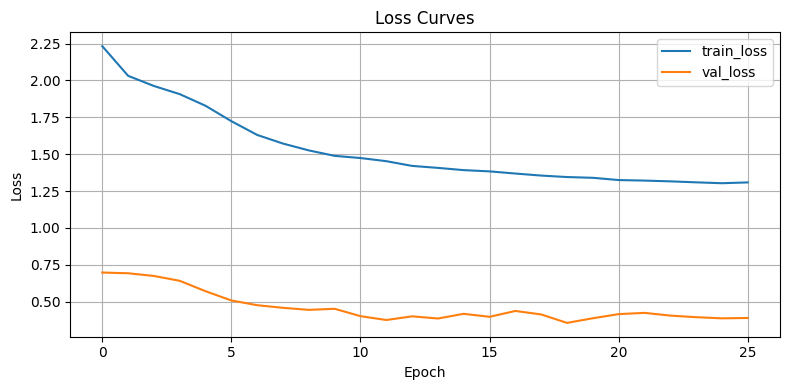

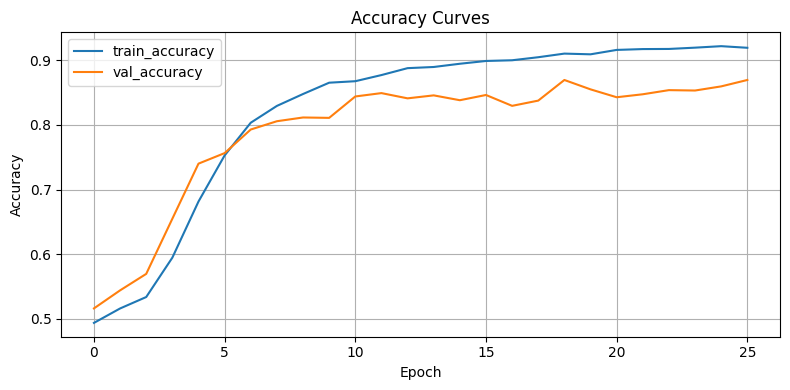

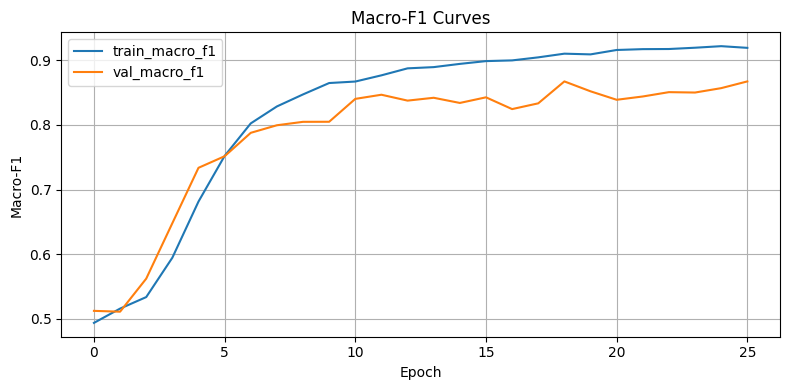

Curves saved to /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/artifacts


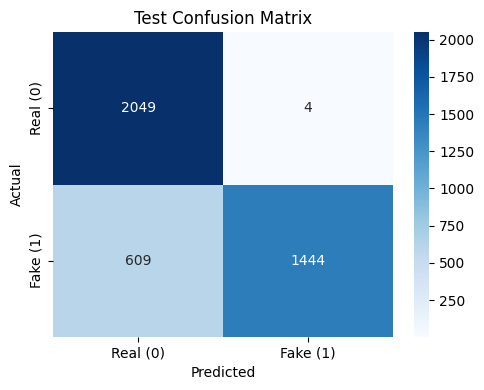

In [16]:
def plot_training_curves(history, artifact_dir):
    """Plot and save loss, accuracy, and macro-F1 training curves."""
    epochs = [r["epoch"] for r in history]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, [r["train_loss"] for r in history], label="train_loss")
    ax.plot(epochs, [r["val_loss"] for r in history], label="val_loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Loss Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(artifact_dir / "loss_curves.png", dpi=120)
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, [r["train_accuracy"] for r in history], label="train_accuracy")
    ax.plot(epochs, [r["val_accuracy"] for r in history], label="val_accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(artifact_dir / "accuracy_curves.png", dpi=120)
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(epochs, [r["train_macro_f1"] for r in history], label="train_macro_f1")
    ax.plot(epochs, [r["val_macro_f1"] for r in history], label="val_macro_f1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Macro-F1 Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(artifact_dir / "macro_f1_curves.png", dpi=120)
    plt.show()
    plt.close()


def plot_confusion_matrix(confusion_matrix_data, artifact_dir):
    """Plot and save the test confusion matrix heatmap."""
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_arr = np.array(confusion_matrix_data)
    sns.heatmap(
        cm_arr,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real (0)", "Fake (1)"],
        yticklabels=["Real (0)", "Fake (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Test Confusion Matrix")
    plt.tight_layout()
    plt.savefig(artifact_dir / "test_confusion_matrix.png", dpi=120)
    plt.show()
    plt.close()


if history:
    plot_training_curves(history, artifact_dir)
    print(f"Curves saved to {artifact_dir}")

if test_metrics.get("confusion_matrix"):
    plot_confusion_matrix(test_metrics["confusion_matrix"], artifact_dir)

# Log artifacts to MLflow
if mlflow_enabled:
    try:
        for _art_file in [
            "training_history.json",
            "training_history.csv",
            "test_report.json",
            "loss_curves.png",
            "accuracy_curves.png",
            "macro_f1_curves.png",
            "test_confusion_matrix.png",
        ]:
            _p = artifact_dir / _art_file
            if _p.exists():
                mlflow.log_artifact(str(_p))
    except Exception as _e:
        print(f"MLflow artifact logging failed (non-fatal): {_e}")

In [17]:
# ── Write checkpoint_manifest.json ─────────────────────────────────────────
manifest_path = run_dir / "checkpoint_manifest.json"
write_checkpoint_manifest(
    manifest_path,
    best_ckpt_path,
    best_epoch,
    test_report,
    compute_config_hash(CONFIG),
    mlflow_enabled,
    mlflow_run_id,
)

if mlflow_enabled:
    try:
        mlflow.log_artifact(str(manifest_path))
    except Exception:
        pass

Manifest written: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/checkpoint_manifest.json


## Step 11: Stage 2 Handoff Sanity Check

Runs one test batch through the reloaded model and prints each Stage 1 output key with its tensor shape,
confirming the Phase 4 feature extraction contract before the notebook ends.


In [18]:
def stage2_handoff_sanity_check(model, sample_batch, device):
    """Verify Stage 1 output keys and shapes for Phase 4 contract."""
    caption, image, _ = sample_batch
    caption, image = caption.to(device), image.to(device)
    with torch.no_grad():
        out = model(caption, image)
        det_probs = F.softmax(out["detection_logits"], dim=-1)
    return {
        "text_aligned_clip": out["text_aligned_clip"],
        "image_aligned_clip": out["image_aligned_clip"],
        "attention_weights": out["attention_weights"],
        "detection_logits": out["detection_logits"],
        "fake_prob": det_probs[:, 1],
    }


_sample = next(iter(loaders["test"]))
_stage2_outputs = stage2_handoff_sanity_check(eval_model, _sample, DEVICE)

print("Stage 2 output key shapes (from reloaded best checkpoint):")
for k, v in _stage2_outputs.items():
    print(f"  {k}: {tuple(v.shape)}")

Stage 2 output key shapes (from reloaded best checkpoint):
  text_aligned_clip: (32, 64)
  image_aligned_clip: (32, 64)
  attention_weights: (32, 3)
  detection_logits: (32, 2)
  fake_prob: (32,)


In [19]:
# ── FINAL SUMMARY ──────────────────────────────────────────────────────────
print("=" * 60)
print("COOLANT Stage 1 Training Complete")
print("=" * 60)
print(f"Best checkpoint:  {best_ckpt_path}")
print(f"Manifest:         {manifest_path}")
print(f"Selection metric: val_accuracy = {best_val_acc:.4f}  (epoch {best_epoch})")
print(f"Test accuracy:    {test_metrics.get('test_accuracy', 'N/A')}")
print(f"Test macro-F1:    {test_metrics.get('test_macro_f1', 'N/A')}")
print()
print("Stage 1 output keys for Phase 4 extractor:")
for _k in [
    "text_aligned_clip",
    "image_aligned_clip",
    "attention_weights",
    "detection_logits",
    "fake_prob",
]:
    print(f"  • {_k}")
print()
print(f"Phase 4 notebook: notebooks/pipeline/04_mm_vifactcheck_integration.ipynb")

# End MLflow run cleanly
if mlflow_enabled:
    try:
        mlflow.end_run()
        print(f"\nMLflow run ended: {mlflow_run_id}")
    except Exception:
        pass

COOLANT Stage 1 Training Complete
Best checkpoint:  /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/best_model.pth
Manifest:         /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_coolant/coolant_stage1_20260610_020928/checkpoint_manifest.json
Selection metric: val_accuracy = 0.8695  (epoch 18)
Test accuracy:    0.8507
Test macro-F1:    0.8474

Stage 1 output keys for Phase 4 extractor:
  • text_aligned_clip
  • image_aligned_clip
  • attention_weights
  • detection_logits
  • fake_prob

Phase 4 notebook: notebooks/pipeline/04_mm_vifactcheck_integration.ipynb
